# Last Mile Logistics Auditor
**Client:** Veridi Logistics | **Dataset:** Olist Brazilian E-Commerce

Audit delivery promise accuracy and link logistics performance to customer sentiment.

## 1. Imports

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

sns.set_theme(style='whitegrid')
pd.set_option('display.float_format', '{:.2f}'.format)

## 2. File Paths

Uses relative paths. Data is expected in an `archive/` subfolder next to the notebook.

In [2]:
DATA_DIR = 'archive'

def path(filename):
    return os.path.join(DATA_DIR, filename)

os.makedirs('outputs', exist_ok=True)

## 3. Load CSVs

In [3]:
orders      = pd.read_csv(path('olist_orders_dataset.csv'))
reviews     = pd.read_csv(path('olist_order_reviews_dataset.csv'))
customers   = pd.read_csv(path('olist_customers_dataset.csv'))
products    = pd.read_csv(path('olist_products_dataset.csv'))
order_items = pd.read_csv(path('olist_order_items_dataset.csv'))
translations = pd.read_csv(path('product_category_name_translation.csv'))

for name, df in [('orders', orders), ('reviews', reviews), ('customers', customers),
                 ('products', products), ('order_items', order_items), ('translations', translations)]:
    print(f'{name:15s}: {df.shape[0]:>7,} rows  {df.shape[1]} cols')

orders         :  99,441 rows  8 cols
reviews        :  99,224 rows  7 cols
customers      :  99,441 rows  5 cols
products       :  32,951 rows  9 cols
order_items    : 112,650 rows  7 cols
translations   :      71 rows  2 cols


## 4. Convert Date Columns

In [4]:
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
]
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

print('Missing actual delivery dates:', orders['order_delivered_customer_date'].isna().sum())

Missing actual delivery dates: 2965


## 5. Aggregate Reviews to One Row per Order

The reviews table can have multiple rows per order. We aggregate before joining to avoid duplicate order rows.

In [5]:
review_summary = (
    reviews.groupby('order_id')
    .agg(avg_review_score=('review_score', 'mean'),
         review_count=('review_id', 'count'))
    .reset_index()
)
print('review_summary rows:', len(review_summary))
print('Duplicate order_ids in review_summary:', review_summary['order_id'].duplicated().sum())

review_summary rows: 98673
Duplicate order_ids in review_summary: 0


## 6. Build Master Dataset (Story 1 — Schema Builder)

Join orders → customers → aggregated reviews. One row = one order.

In [6]:
master = (
    orders
    .merge(customers[['customer_id', 'customer_state', 'customer_city']], on='customer_id', how='left')
    .merge(review_summary, on='order_id', how='left')
)

# Join validation
print('Orders rows    :', len(orders))
print('Master rows    :', len(master))
print('Unique order_id:', master['order_id'].nunique())
assert len(master) == len(orders), 'Row count mismatch — check for duplicates!'
print('✓ No duplicate rows introduced.')

Orders rows    : 99441
Master rows    : 99441


Unique order_id: 99441
✓ No duplicate rows introduced.


## 7. Delay Metrics (Story 2 — Delay Calculator)

`Days_Difference` = estimated − actual. Positive = early, negative = late.

In [7]:
master['Days_Difference'] = (
    (master['order_estimated_delivery_date'] - master['order_delivered_customer_date'])
    .dt.days
)

# Delay_Days: 0 if on time/early, positive number if late
master['Delay_Days'] = master['Days_Difference'].apply(lambda x: max(0, -x) if pd.notna(x) else np.nan)

def classify(row):
    if pd.isna(row['order_delivered_customer_date']):
        return 'Not Delivered'
    if row['Days_Difference'] >= 0:
        return 'On Time'
    if row['Days_Difference'] >= -5:
        return 'Late'
    return 'Super Late'

master['Delivery_Status'] = master.apply(classify, axis=1)
master['is_late'] = master['Delivery_Status'].isin(['Late', 'Super Late'])

print(master['Delivery_Status'].value_counts())

Delivery_Status
On Time          88649
Super Late        4212
Late              3615
Not Delivered     2965
Name: count, dtype: int64


## 8. National Delivery Performance Overview

In [8]:
delivered = master[master['Delivery_Status'] != 'Not Delivered'].copy()

total_delivered   = len(delivered)
late_orders       = delivered['is_late'].sum()
super_late_orders = (delivered['Delivery_Status'] == 'Super Late').sum()
national_late_rate     = late_orders / total_delivered
national_super_late    = super_late_orders / total_delivered
national_avg_review    = delivered['avg_review_score'].mean()

print(f'Total Delivered Orders : {total_delivered:,}')
print(f'Late or Super Late     : {late_orders:,}  ({national_late_rate:.1%})')
print(f'Super Late (>5 days)   : {super_late_orders:,}  ({national_super_late:.1%})')
print(f'Avg Review Score       : {national_avg_review:.2f} / 5')

Total Delivered Orders : 96,476
Late or Super Late     : 7,827  (8.1%)
Super Late (>5 days)   : 4,212  (4.4%)
Avg Review Score       : 4.16 / 5


## 9. Late Delivery Rate by State (Story 3 — Geographic Analysis)

In [9]:
state_summary = (
    delivered.groupby('customer_state')
    .agg(
        delivered_orders=('order_id', 'count'),
        late_orders=('is_late', 'sum'),
        super_late_orders=('Delivery_Status', lambda x: (x == 'Super Late').sum()),
        avg_delay_days=('Delay_Days', 'mean'),
        avg_review_score=('avg_review_score', 'mean'),
    )
    .reset_index()
)
state_summary['late_rate']       = state_summary['late_orders'] / state_summary['delivered_orders']
state_summary['super_late_rate'] = state_summary['super_late_orders'] / state_summary['delivered_orders']
state_summary = state_summary.sort_values('late_rate', ascending=False)

state_summary.to_csv('outputs/state_delivery_summary.csv', index=False)
print(state_summary[['customer_state', 'delivered_orders', 'late_rate', 'avg_review_score']].head(10).to_string(index=False))

customer_state  delivered_orders  late_rate  avg_review_score
            AL               397       0.24              3.85
            MA               717       0.20              3.83
            PI               476       0.16              3.99
            CE              1279       0.15              3.94
            SE               335       0.15              3.91
            BA              3256       0.14              3.93
            RJ             12353       0.13              3.96
            TO               274       0.13              4.15
            PA               946       0.12              3.91
            ES              1995       0.12              4.08


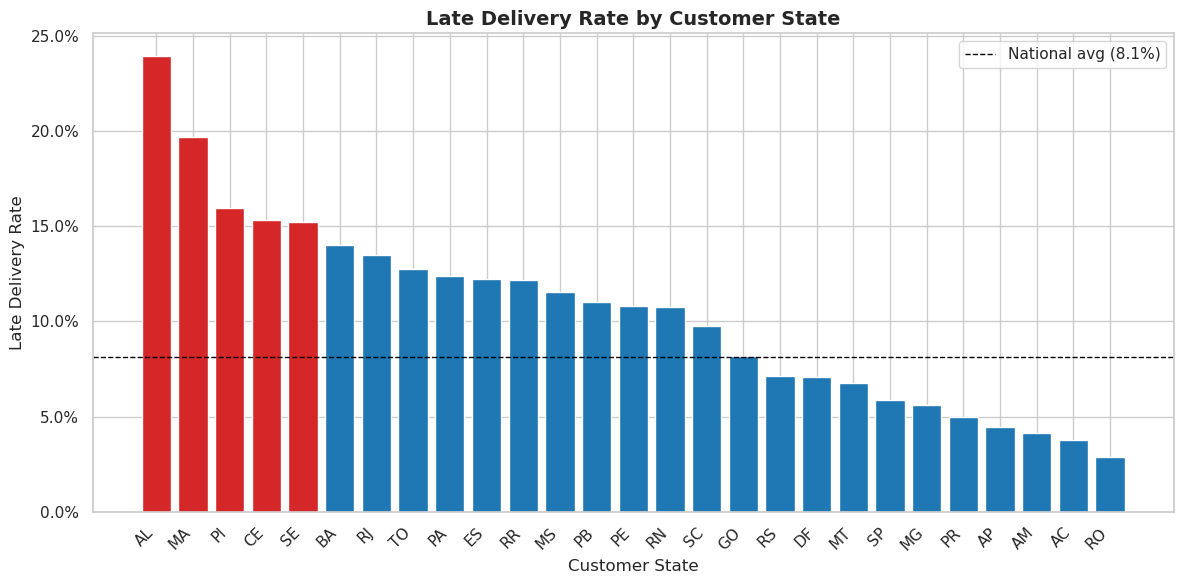

In [10]:
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(
    state_summary['customer_state'],
    state_summary['late_rate'],
    color=['#d62728' if r > 0.15 else '#1f77b4' for r in state_summary['late_rate']]
)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title('Late Delivery Rate by Customer State', fontsize=14, fontweight='bold')
ax.set_xlabel('Customer State')
ax.set_ylabel('Late Delivery Rate')
ax.axhline(national_late_rate, color='black', linestyle='--', linewidth=1, label=f'National avg ({national_late_rate:.1%})')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('outputs/late_rate_by_state.png', dpi=150)
plt.show()

## 10. Sentiment vs Delivery Status (Story 4 — Sentiment Correlation)

In [11]:
sentiment_summary = (
    delivered.groupby('Delivery_Status')
    .agg(
        order_count=('order_id', 'count'),
        avg_review_score=('avg_review_score', 'mean')
    )
    .reset_index()
)
status_order = ['On Time', 'Late', 'Super Late']
sentiment_summary['Delivery_Status'] = pd.Categorical(sentiment_summary['Delivery_Status'], categories=status_order, ordered=True)
sentiment_summary = sentiment_summary.sort_values('Delivery_Status')

sentiment_summary.to_csv('outputs/sentiment_by_delivery_status.csv', index=False)
print(sentiment_summary.to_string(index=False))

Delivery_Status  order_count  avg_review_score
        On Time        88649              4.29
           Late         3615              3.46
     Super Late         4212              1.79


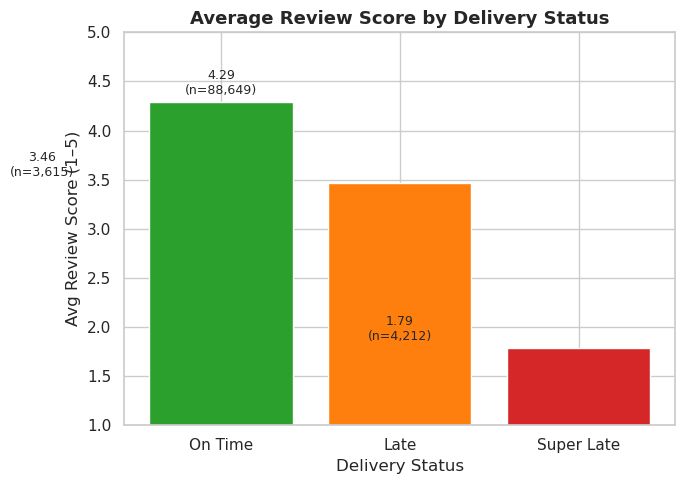

In [12]:
fig, ax = plt.subplots(figsize=(7, 5))
colors = ['#2ca02c', '#ff7f0e', '#d62728']
ax.bar(sentiment_summary['Delivery_Status'], sentiment_summary['avg_review_score'], color=colors)
ax.set_ylim(1, 5)
ax.set_title('Average Review Score by Delivery Status', fontsize=13, fontweight='bold')
ax.set_xlabel('Delivery Status')
ax.set_ylabel('Avg Review Score (1–5)')
for i, row in sentiment_summary.iterrows():
    ax.text(i - sentiment_summary.index[0], row['avg_review_score'] + 0.05,
            f"{row['avg_review_score']:.2f}\n(n={row['order_count']:,})",
            ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('outputs/sentiment_by_status.png', dpi=150)
plt.show()

## 11. Review Score by Delay Bucket

In [13]:
bins   = [-1, 0, 2, 5, 10, 20, float('inf')]
labels = ['0 (On Time/Early)', '1–2 days', '3–5 days', '6–10 days', '11–20 days', '21+ days']
delivered['delay_bucket'] = pd.cut(delivered['Delay_Days'], bins=bins, labels=labels)

bucket_summary = (
    delivered.groupby('delay_bucket', observed=True)
    .agg(order_count=('order_id', 'count'), avg_review_score=('avg_review_score', 'mean'))
    .reset_index()
)
bucket_summary.to_csv('outputs/delay_bucket_review_summary.csv', index=False)
print(bucket_summary.to_string(index=False))

     delay_bucket  order_count  avg_review_score
0 (On Time/Early)        88649              4.29
         1–2 days         2117              3.92
         3–5 days         1498              2.81
        6–10 days         1912              1.89
       11–20 days         1416              1.66
         21+ days          884              1.76


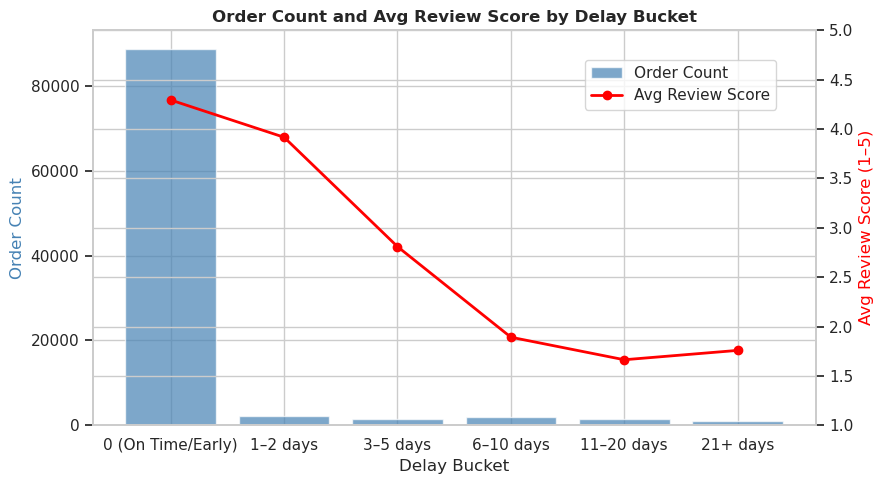

In [14]:
fig, ax1 = plt.subplots(figsize=(9, 5))
ax2 = ax1.twinx()
ax1.bar(bucket_summary['delay_bucket'], bucket_summary['order_count'], color='steelblue', alpha=0.7, label='Order Count')
ax2.plot(bucket_summary['delay_bucket'], bucket_summary['avg_review_score'], color='red', marker='o', linewidth=2, label='Avg Review Score')
ax1.set_xlabel('Delay Bucket')
ax1.set_ylabel('Order Count', color='steelblue')
ax2.set_ylabel('Avg Review Score (1–5)', color='red')
ax2.set_ylim(1, 5)
ax1.set_title('Order Count and Avg Review Score by Delay Bucket', fontsize=12, fontweight='bold')
plt.xticks(rotation=30, ha='right')
fig.legend(loc='upper right', bbox_to_anchor=(0.88, 0.88))
plt.tight_layout()
plt.savefig('outputs/delay_bucket_sentiment.png', dpi=150)
plt.show()

## 12. Product Category Translation (Bonus Story)

Translate Portuguese product category names to English using the provided translation table.

In [15]:
products_en = products.merge(translations, on='product_category_name', how='left')
products_en['product_category_name_english'] = (
    products_en['product_category_name_english']
    .fillna(products_en['product_category_name'])
    .fillna('unknown')
)
print('Products with English category:', products_en['product_category_name_english'].notna().sum())

Products with English category: 32951


## 13. Candidate's Choice — Product Category Delivery Risk

Some product categories may be harder to ship due to size, weight, fragility, or supplier location.
This analysis identifies which categories have the highest late-delivery rates and lowest review scores,
helping Veridi target operational improvements beyond geography.

In [16]:
# Aggregate order_items to one dominant category per order
items_with_category = (
    order_items[['order_id', 'product_id']]
    .merge(products_en[['product_id', 'product_category_name_english']], on='product_id', how='left')
)

order_category = (
    items_with_category.groupby('order_id')['product_category_name_english']
    .agg(lambda x: x.mode()[0] if len(x) > 0 else 'unknown')
    .reset_index()
    .rename(columns={'product_category_name_english': 'category'})
)

delivered_cat = delivered.merge(order_category, on='order_id', how='left')

category_summary = (
    delivered_cat.groupby('category')
    .agg(
        delivered_orders=('order_id', 'count'),
        late_orders=('is_late', 'sum'),
        avg_delay_days=('Delay_Days', 'mean'),
        avg_review_score=('avg_review_score', 'mean'),
    )
    .reset_index()
)
category_summary['late_rate'] = category_summary['late_orders'] / category_summary['delivered_orders']

# Filter to categories with at least 100 delivered orders
category_summary = category_summary[category_summary['delivered_orders'] >= 100].sort_values('late_rate', ascending=False)

category_summary.to_csv('outputs/category_delivery_summary.csv', index=False)
print(category_summary[['category', 'delivered_orders', 'late_rate', 'avg_review_score']].head(15).to_string(index=False))

                       category  delivered_orders  late_rate  avg_review_score
                          audio               348       0.13              3.84
        fashion_underwear_beach               117       0.13              4.01
                   home_confort               346       0.11              3.95
                books_technical               256       0.11              4.43
                           food               436       0.10              4.32
                    electronics              2509       0.10              4.13
             christmas_supplies               125       0.10              4.11
      construction_tools_lights               237       0.09              4.18
               office_furniture              1244       0.09              3.65
                           baby              2794       0.09              4.11
construction_tools_construction               731       0.09              4.14
                  health_beauty              8623   

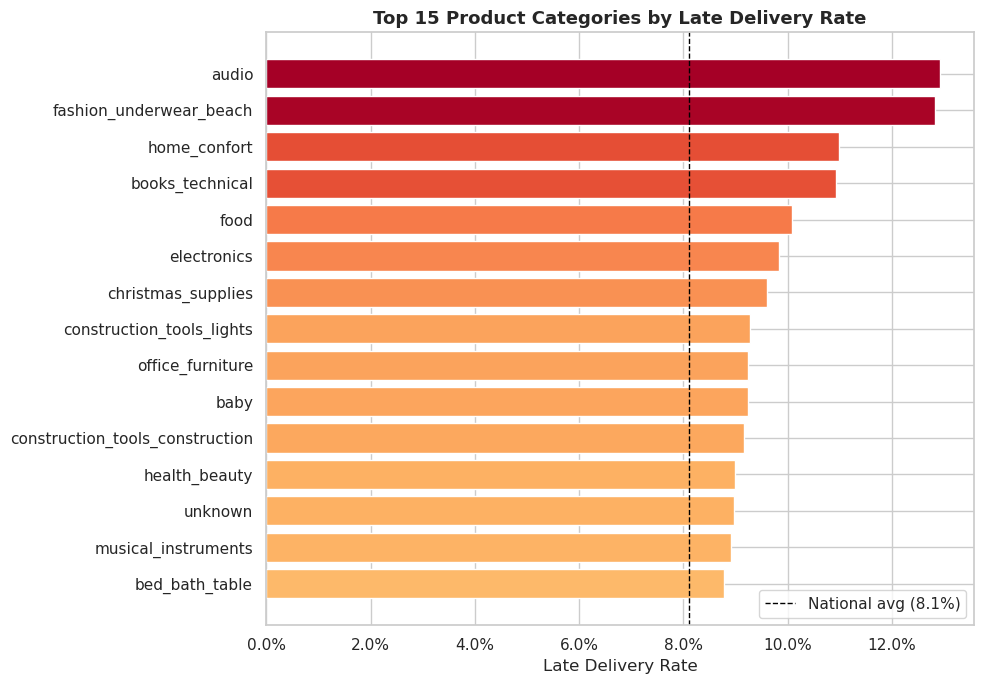

In [17]:
top15 = category_summary.head(15)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(top15['category'][::-1], top15['late_rate'][::-1],
               color=plt.cm.RdYlGn_r(top15['late_rate'][::-1] / top15['late_rate'].max()))
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title('Top 15 Product Categories by Late Delivery Rate', fontsize=13, fontweight='bold')
ax.set_xlabel('Late Delivery Rate')
ax.axvline(national_late_rate, color='black', linestyle='--', linewidth=1, label=f'National avg ({national_late_rate:.1%})')
ax.legend()
plt.tight_layout()
plt.savefig('outputs/category_late_rate.png', dpi=150)
plt.show()

## 14. Final Metrics Summary (for README)

In [18]:
worst_state = state_summary.iloc[0]
best_status = sentiment_summary.loc[sentiment_summary['Delivery_Status'] == 'On Time', 'avg_review_score'].values[0]
worst_status = sentiment_summary.loc[sentiment_summary['Delivery_Status'] == 'Super Late', 'avg_review_score'].values[0]
worst_cat = category_summary.iloc[0]

print('=== README-READY METRICS ===')
print(f'Total delivered orders    : {total_delivered:,}')
print(f'National late rate         : {national_late_rate:.1%}')
print(f'National super-late rate   : {national_super_late:.1%}')
print(f'Avg review score           : {national_avg_review:.2f}/5')
print(f'Worst state                : {worst_state["customer_state"]} ({worst_state["late_rate"]:.1%} late rate)')
print(f'On-time avg review score   : {best_status:.2f}/5')
print(f'Super-late avg review score: {worst_status:.2f}/5')
print(f'Highest-risk category      : {worst_cat["category"]} ({worst_cat["late_rate"]:.1%} late rate)')

=== README-READY METRICS ===
Total delivered orders    : 96,476
National late rate         : 8.1%
National super-late rate   : 4.4%
Avg review score           : 4.16/5
Worst state                : AL (23.9% late rate)
On-time avg review score   : 4.29/5
Super-late avg review score: 1.79/5
Highest-risk category      : audio (12.9% late rate)
